# Studying the final neutron star population

In [19]:
import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=False)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [20]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "25"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

Select an `final_population.pkl.gz` file to import:

In [21]:
data = pd.read_pickle("../data/final_population.pkl.gz", compression="gzip")
data.head()

,age,x,y,z,RA,DEC,d,v_r,v_phi,v_z,v_RA,v_DEC,v_ls
,[yr],[kpc],[kpc],[kpc],[deg],[deg],[kpc],[km/s],[km/s],[km/s],[mas/yr],[mas/yr],[km/s]
0,5.434050e+06,-7.035422,1.294045,0.799852,214.648456,-56.249436,9.959338,268.350012,-455.393091,94.798539,-13.870767,-2.850539,-49.731853
1,2.783695e+06,-13.479558,-2.495809,-0.844645,206.609930,-65.034226,17.291474,-93.893103,-352.024681,-287.466721,-4.341300,-4.672644,-50.626044
2,4.245176e+06,-4.058120,2.481674,0.736529,229.140540,-50.638311,7.129824,-335.570250,-125.302704,147.409096,0.769305,5.384596,-1.225772
3,8.447761e+06,-1.659401,9.877509,-0.527062,96.552905,-18.016958,2.354039,540.279760,-512.369762,-57.802533,-20.742070,47.103790,317.870206
4,4.718956e+04,-5.627567,-2.313760,-0.705526,247.429202,-53.375049,12.035252,-12.946762,-17.661375,-436.285338,2.839050,-8.183769,109.027917


In [22]:
x = data["x"]["[kpc]"].to_numpy()
y = data["y"]["[kpc]"].to_numpy()
z = data["z"]["[kpc]"].to_numpy()
RA = data["RA"]["[deg]"].to_numpy()
DEC = data["DEC"]["[deg]"].to_numpy()
v_RA = data["v_RA"]["[mas/yr]"].to_numpy()
v_DEC = data["v_DEC"]["[mas/yr]"].to_numpy()

Top view of the galactic plane

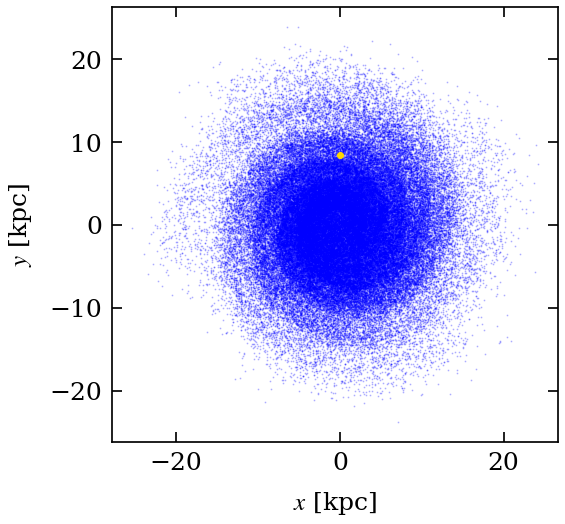

In [23]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.2,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")

plt.show()

Zoomed-in top view of the galactic plane

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Side view of the galactic plane

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")

plt.show()

Zoomed-in side view of the galactic plane

In [ ]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Histrogramming the pulsars position and comparing to underlying initial position PDF

In [ ]:
def pdf_r(r):
    "pdf from the Milky Way stellar surface density (Yusifov & Küçük 2004)"
    A = 37.6  # [stars kpc^-2]
    R1 = 0.55  # +-0.1 [kpc]
    Rsun = 8.5
    a = 1.64  # +-0.11
    b = 4.01  # +-0.24
    rho = (
        A
        * ((r + R1) / (Rsun + R1)) ** a
        * np.exp(-b * ((r - Rsun) / (Rsun + R1)))
    )
    pdf_r = 2 * np.pi * r * rho
    return pdf_r

In [ ]:
# r_bins = np.logspace(np.log10(0.0001), np.log10(100.), 100)
r_bins = np.linspace(0.0, 100.0, 120)

r = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots()

ax.hist(
    r,
    bins=r_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label="radial dist evolved NS",
)
ax.plot(
    r_bins,
    pdf_r(r_bins),
    linestyle="-",
    lw=4,
    color="red",
    alpha=0.5,
    label="initial radial dist (Yusifov \& Kucuk 2004)",
)
plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"number of NS")
plt.xlim(0.0, 100.0)
plt.legend(frameon=False, loc=0)

plt.show()

Plotting the distribution of simulated pulsars in RA and DEC in the ICRS (International Celestial Reference System) frame and comparing with neutron stars in the ATNF catalogue.

In [ ]:
data_atnf = pd.read_csv("../data/ATNF_pulsars_20-05-2020.csv", delimiter=',', header=[0,1])
data_atnf.head()

In [ ]:
RA_atnf = coord.Angle(data_atnf["RAJ"].values, unit=u.hourangle)
DEC_atnf = coord.Angle(data_atnf["DECJ"].values, unit=u.deg)

# Convert RA and DEC in degrees and transform to np.array
icrs_coord = coord.ICRS(ra=RA_atnf, dec=DEC_atnf)

RA_atnf = np.array(icrs_coord.ra.degree / u.deg)
DEC_atnf = np.array(icrs_coord.dec.degree / u.deg)

In [ ]:
RA_galcen = 266.4
DEC_galcen = -29.0

fig, ax = plt.subplots()

ax.plot(
    RA, 
    DEC, 
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)
ax.plot(
    RA_atnf, 
    DEC_atnf, 
    linestyle="None",
    marker="o",
    color="red",
    markersize=3,
    alpha=0.3,
    rasterized=True,
)

ax.plot(RA_galcen, DEC_galcen, marker="X", color="gold", markersize=10)
ax.set_xlim(0., 360.)
ax.set_ylim(-90., 90.)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('DEC [deg]')

plt.show()

Histrogramming the simulated pulsars RA and DEC coordinate position and comparing with the observed neutron stars in the ATNF catalogue.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

RA_bins = np.linspace(0., 360., 50)
DEC_bins = np.linspace(-90., 90., 50)

ax1.hist(
    RA,
    bins=RA_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=1,
    label=r"simulated",
    density=1,
)
ax1.hist(
    RA_atnf,
    bins=RA_bins,
    histtype="stepfilled",
    edgecolor="red",
    lw=0.01,
    alpha=0.5,
    label=r"observed",
    density=1,
)
ax1.set_xlabel(r"RA [deg]")
ax1.set_ylabel(r"normalized count")
ax1.legend(frameon=False, loc=0)

ax2.hist(
    DEC,
    bins=DEC_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=1,
    label=r"simulated",
    density=1,
)
ax2.hist(
    DEC_atnf,
    bins=DEC_bins,
    histtype="stepfilled",
    edgecolor="red",
    lw=0.01,
    alpha=0.5,
    label=r"observed",
    density=1,
)
ax2.set_xlabel(r"DEC [deg]")
ax2.set_ylabel(r"normalized count")
ax2.legend(frameon=False, loc=0)

plt.show()

Histrogramming the simulated pulsars angular proper velocity in RA and DEC and comparing with the proper velocity of the observed neutron stars.

In [ ]:
data_pm = pd.read_csv("../data/PSRs_prop_motion_22-05-2020.csv", header=[0,1])
data_pm.head()

In [ ]:
v_RA_pm = data_pm["PMRA"]["[mas / yr]"].to_numpy()
v_DEC_pm = data_pm["PMDEC"]["[mas / yr]"].to_numpy()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

x_bins = np.linspace(-50, 50, 50)

ax1.hist(
    v_RA,
    bins=x_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=1,
    label=r"simulated",
    density=1,
)
ax1.hist(
    v_RA_pm,
    bins=x_bins,
    histtype="stepfilled",
    edgecolor="red",
    lw=0.01,
    alpha=0.5,
    label=r"observed",
    density=1,
)
ax1.set_xlabel(r"$v_{\rm RA}$ [mas yr$^{-1}$]")
ax1.set_ylabel(r"normalized count")
ax1.legend(frameon=False, loc=0)

ax2.hist(
    v_DEC,
    bins=x_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=1,
    label=r"simulated",
    density=1,
)
ax2.hist(
    v_DEC_pm,
    bins=x_bins,
    histtype="stepfilled",
    edgecolor="red",
    lw=0.01,
    alpha=0.5,
    label=r"observed",
    density=1,
)
ax2.set_xlabel(r"$v_{\rm DEC}$ [mas yr$^{-1}$]")
ax2.set_ylabel(r"normalized count")
ax2.legend(frameon=False, loc=0)

plt.show()